In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import time
from scipy.stats import randint
from skopt.space import Integer

from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler, QuantileTransformer, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, RFE # Note: f_regression used here!
from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.manifold import TSNE
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

df = pd.read_csv(r"C:\Users\sahay\OneDrive\Desktop\Regression_Problem\DelhiAQI.csv")

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

X = df.drop('AQI', axis=1)
y = df['AQI']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.40, 
    random_state=42 
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.50, 
    random_state=42
)

c:\Users\sahay\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PM2.5    15000 non-null  float64
 1   PM10     15000 non-null  float64
 2   NO       15000 non-null  float64
 3   NO2      15000 non-null  float64
 4   NOx      15000 non-null  float64
 5   NH3      15000 non-null  float64
 6   CO       15000 non-null  float64
 7   SO2      15000 non-null  float64
 8   O3       15000 non-null  float64
 9   Benzene  15000 non-null  float64
 10  Toluene  15000 non-null  float64
 11  Xylene   15000 non-null  float64
 12  AQI      15000 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 1.5 MB
None

SUMMARY STATISTICS
           count        mean         std    min       25%      50%       75%  \
PM2.5    15000.0  113.505115   77.066283   7.18   58.0200   88.335  149.6850   
PM10     15000.0  224.775180  134.662705   5.11  121.2100  199.755  

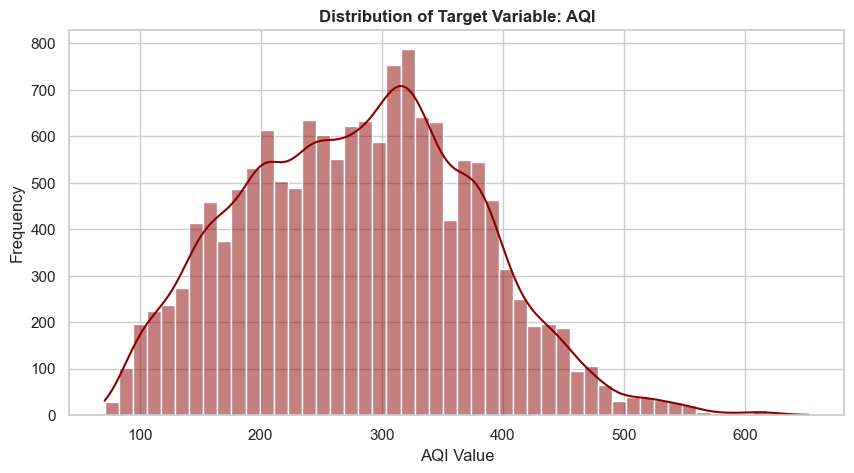

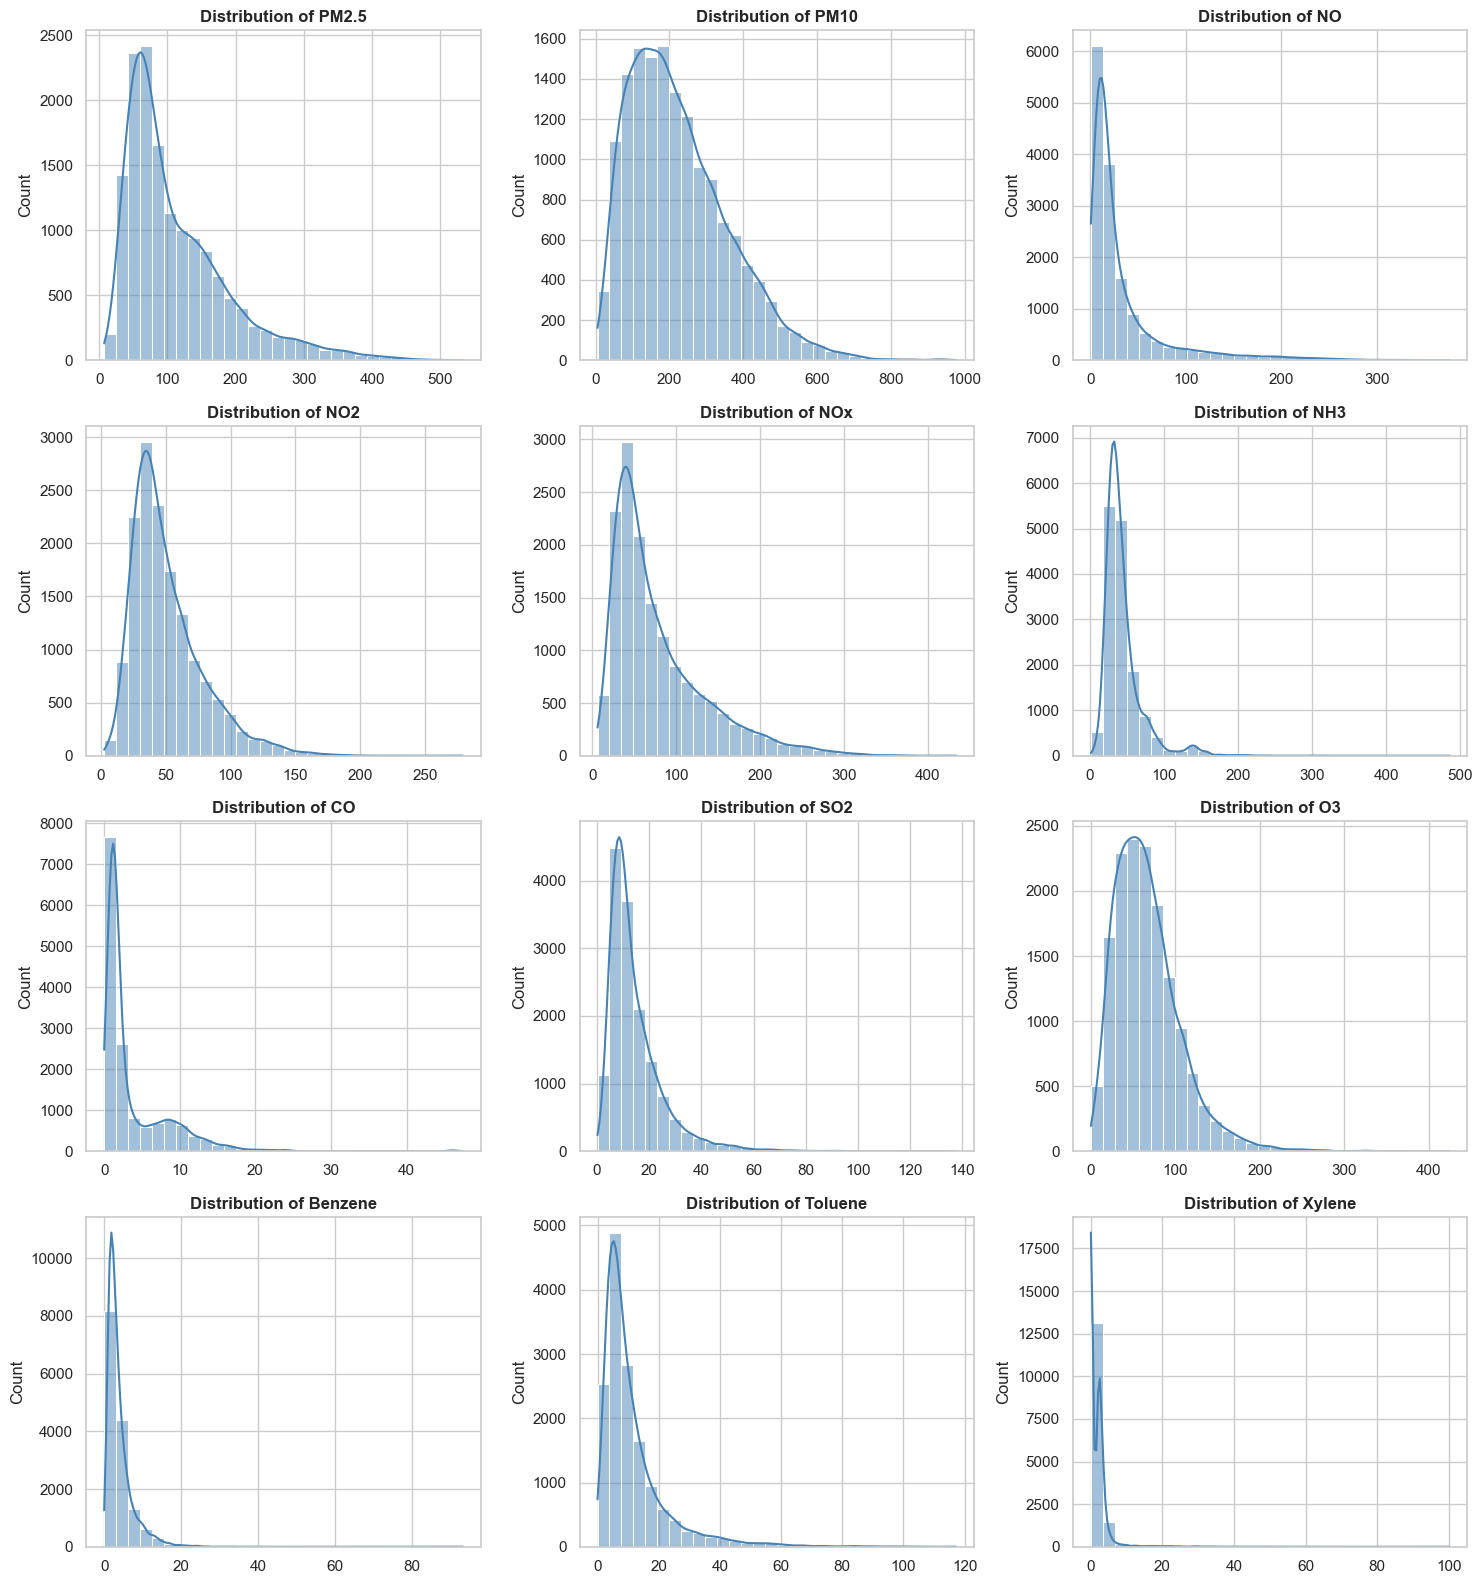

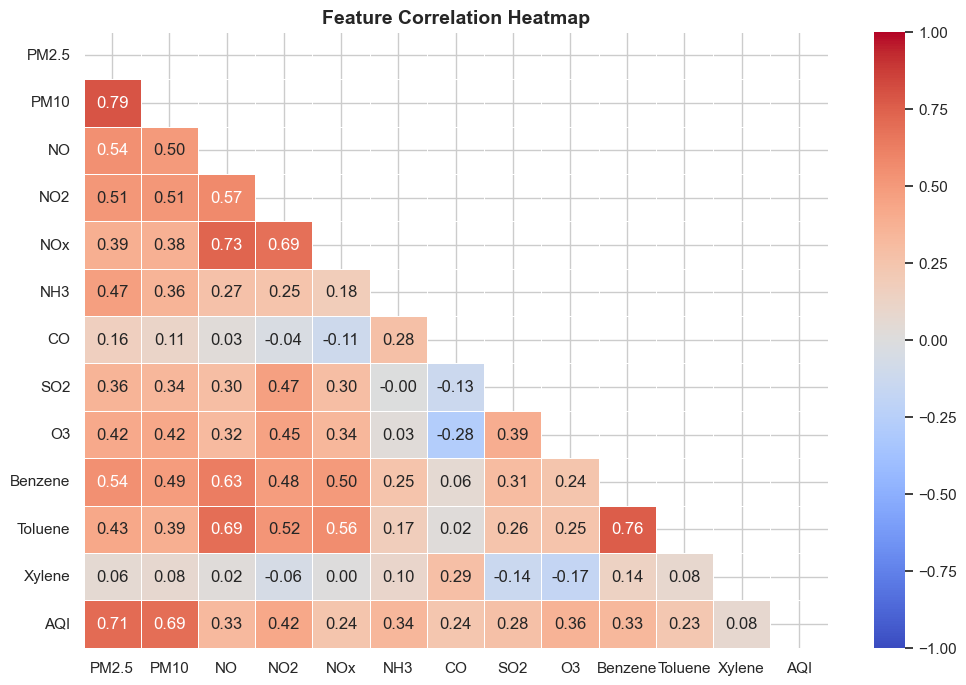

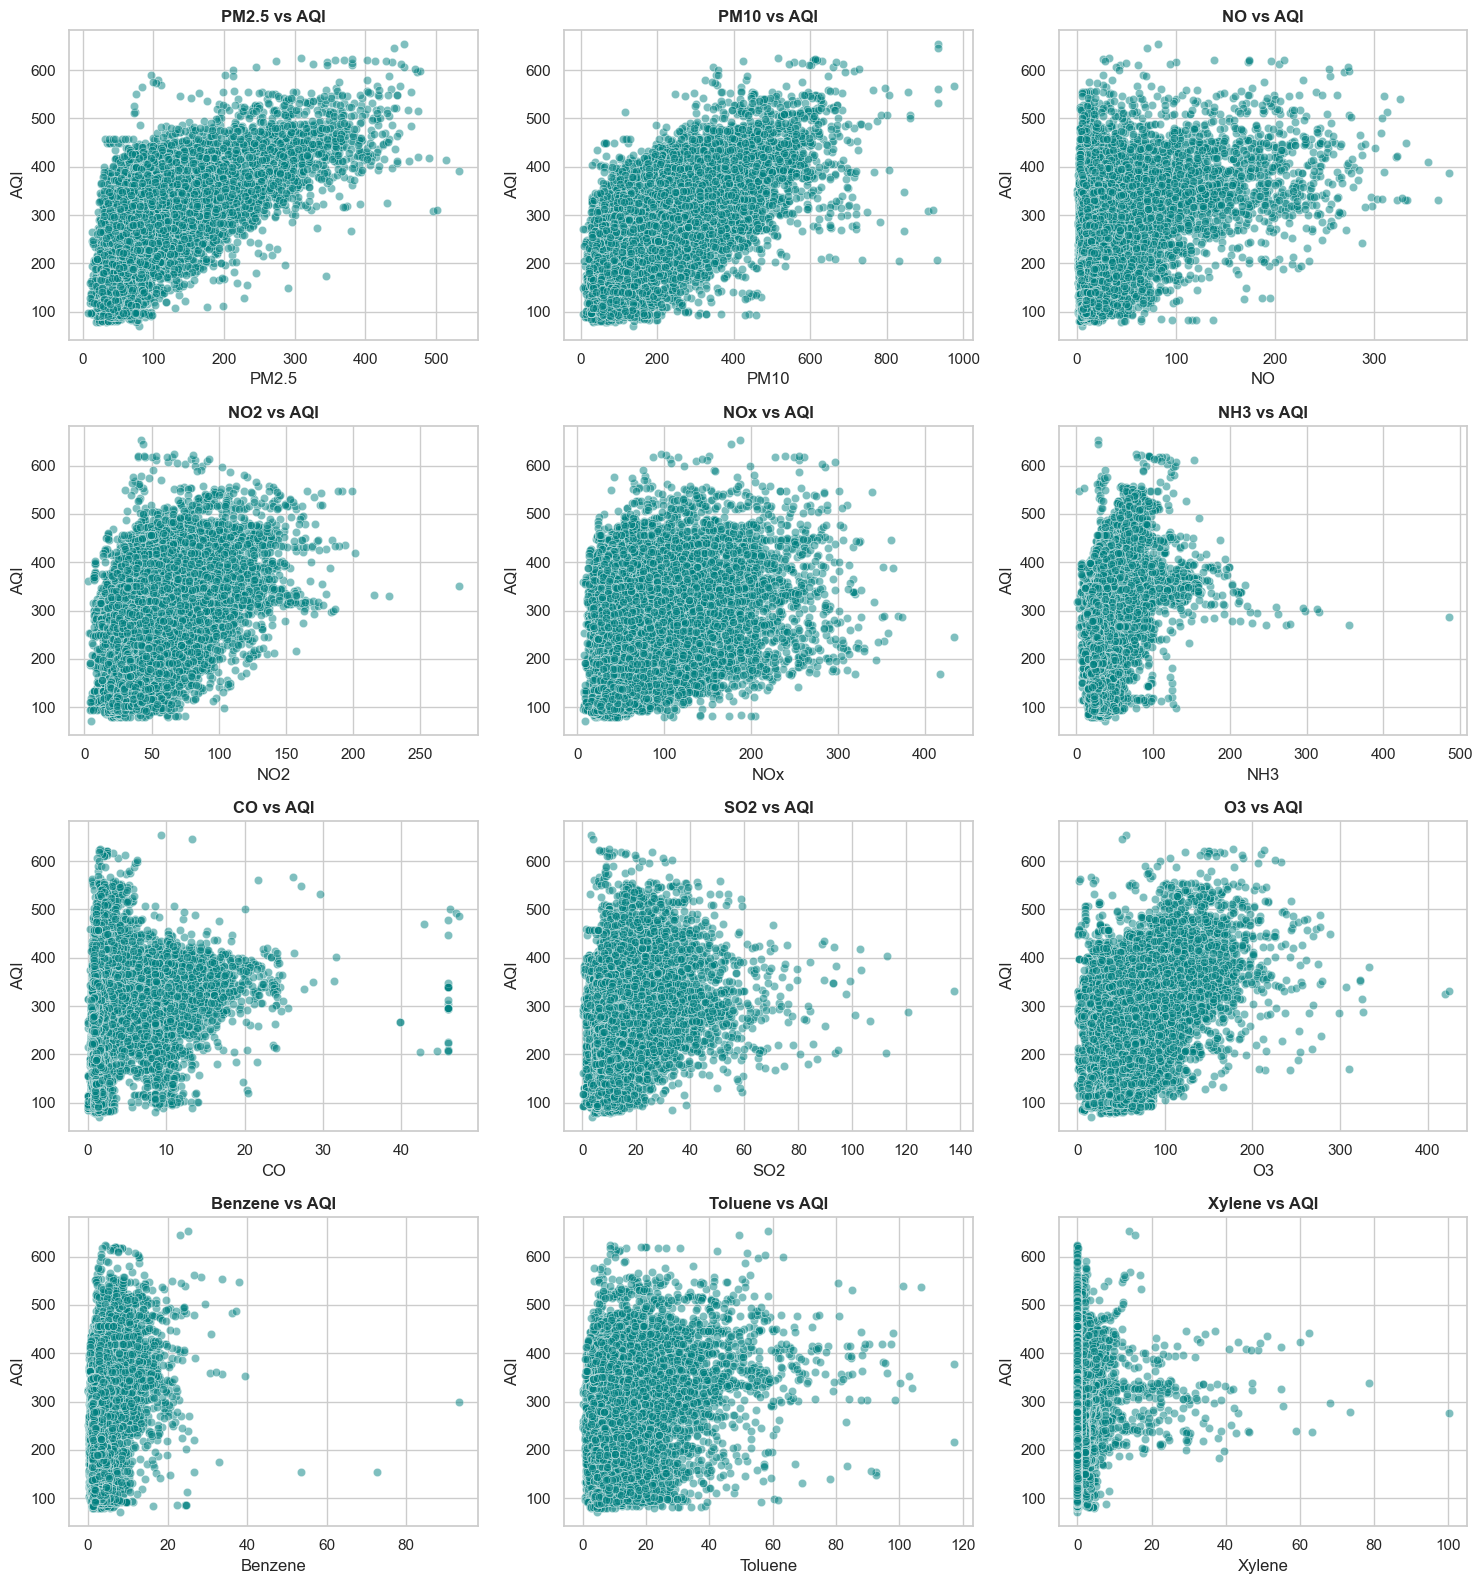

In [2]:
sns.set_theme(style="whitegrid")

print("DATASET OVERVIEW")
print(df.info())
print("\nSUMMARY STATISTICS")
print(df.describe().T)

plt.figure(figsize=(10, 5))
sns.histplot(df['AQI'], bins=50, kde=True, color='darkred')
plt.title('Distribution of Target Variable: AQI', fontweight='bold')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.show()

features = df.drop('AQI', axis=1).columns
num_features = len(features)
rows = int(np.ceil(num_features / 3))

fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Hide upper triangle for clean look

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.show()


fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df['AQI'], ax=axes[i], alpha=0.5, color='teal')
    axes[i].set_title(f'{col} vs AQI', fontweight='bold')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

PIPELINE

In [9]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', None),
    ('extractor', None),
    ('reducer', None),
    ('reg', LinearRegression())
])

# DICTIONARY

scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': PowerTransformer(),
    'quantile': QuantileTransformer(),
    'minmax': MinMaxScaler(),
    'none': 'none'
}

selectors = {
    'kbest': SelectKBest(score_func=f_regression, k=6),
    'rfe': RFE(estimator=RandomForestRegressor(random_state=29), n_features_to_select=6),
    'none': 'none'
}

extractors = {
    'pls_regression': PLSRegression(n_components=3),
    'none': 'none'
}

reducers = {
    'pca': PCA(n_components=0.95),
    'kpca': KernelPCA(n_components=5, kernel='rbf'),
    'ica': FastICA(n_components=5, random_state=29),
    'none': 'none'
}

models = {
    'lr': LinearRegression(),
    'ridge': Ridge(random_state=29),
    'lasso': Lasso(random_state=29),
    'elastic': ElasticNet(random_state=29),
    'bayes_ridge': BayesianRidge(),
    
    'svr': SVR(),
    
    'mlp': MLPRegressor(max_iter=2000, random_state=29),
    
    'rf': RandomForestRegressor(random_state=29),
    'extratrees': ExtraTreesRegressor(random_state=29),
    'adaboost': AdaBoostRegressor(random_state=29),
    'hist_gb': HistGradientBoostingRegressor(random_state=29),
    'xgb': XGBRegressor(eval_metric='rmse', random_state=29),
    'catboost': CatBoostRegressor(verbose=0, random_state=29)
}

FINDING BEST SCALER

In [4]:
pipe.set_params(
    selector=None, 
    extractor=None, 
    reducer=None, 
    reg=RandomForestRegressor(random_state=29)
)

print("The best Scaler is -")
scaler_results = []

for name, scaler in scalers.items():
    pipe_copy = clone(pipe)
    
    pipe_copy.set_params(scaler=scaler if name != 'none' else None)
    
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    scaler_results.append({'Scaler': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name: <10} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

scaler_df = pd.DataFrame(scaler_results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
best_scaler_name = scaler_df.iloc[0]['Scaler']
print(f"\nBest Scaler: {best_scaler_name}")

The best Scaler is -
standard   -> RMSE: 46.1560 | R2: 0.7692
robust     -> RMSE: 46.1664 | R2: 0.7691
power      -> RMSE: 46.1697 | R2: 0.7691
quantile   -> RMSE: 46.1479 | R2: 0.7693
minmax     -> RMSE: 46.1590 | R2: 0.7692
none       -> RMSE: 46.1706 | R2: 0.7690

Best Scaler: quantile


FEATURE SELECTION

In [5]:
pipe.set_params(
    scaler=scalers['quantile'],
    selector=None, 
    extractor=None, 
    reducer=None, 
    reg=RandomForestRegressor(random_state=29)
)

print("The Best Selector is - ")
selector_results = []

for name, selector in selectors.items():
    pipe_copy = clone(pipe)
    
    pipe_copy.set_params(selector=selector if name != 'none' else None)
    
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    selector_results.append({'Selector': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name: <10} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

selector_df = pd.DataFrame(selector_results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
best_selector_name = selector_df.iloc[0]['Selector']
print(f"\n Best Selector : {best_selector_name}")

The Best Selector is - 
kbest      -> RMSE: 52.1163 | R2: 0.7057
rfe        -> RMSE: 51.0195 | R2: 0.7180
none       -> RMSE: 46.1479 | R2: 0.7693

 Best Selector : none


CHOOSING FEATURE EXTRACTION

In [6]:
pipe.set_params(
    scaler=scalers['quantile'],
    selector=None,              
    extractor=None,             
    reducer=None, 
    reg=RandomForestRegressor(random_state=29)
)

print("The Best extractor is - ")
extractor_results = []

for name, extractor in extractors.items():
    pipe_copy = clone(pipe)
    
    pipe_copy.set_params(extractor=extractor if name != 'none' else None)
    
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    extractor_results.append({'Extractor': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name: <15} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")
extractor_df = pd.DataFrame(extractor_results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
best_extractor_name = extractor_df.iloc[0]['Extractor']
print(f"\n Best Extractor : {best_extractor_name}")

The Best extractor is - 


ValueError: Found array with dim 3, while dim <= 2 is required by RandomForestRegressor.

Selection Dimensionality Reduction

In [7]:
pipe.set_params(
    scaler=scalers['quantile'],
    selector=None,              
    extractor=None,             
    reducer=None, 
    reg=RandomForestRegressor(random_state=29)
)

print("The Best Reducer is -  ")
reducer_results = []

for name, reducer in reducers.items():
    pipe_copy = clone(pipe)
    
    pipe_copy.set_params(reducer=reducer if name != 'none' else None)
    
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    reducer_results.append({'Reducer': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name: <10} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

reducer_df = pd.DataFrame(reducer_results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
best_reducer_name = reducer_df.iloc[0]['Reducer']
print(f"\n Best Reducer: {best_reducer_name}")

The Best Reducer is -  
pca        -> RMSE: 48.8144 | R2: 0.7418
kpca       -> RMSE: 53.3079 | R2: 0.6921
ica        -> RMSE: 52.9106 | R2: 0.6967
none       -> RMSE: 46.1479 | R2: 0.7693

 Best Reducer: none


TESTING ALL THE REGRESSORS

In [10]:
pipe.set_params(
    scaler=QuantileTransformer(),
    selector=None,              
    extractor=None,             
    reducer=None                
)
kf = KFold(n_splits=5, shuffle=True, random_state=29)

model_results = []

for name, model in models.items():
    iteration_rmse = []
    iteration_r2 = []
    
    for train_index, test_index in kf.split(X_train):
        
        X_tr, X_te = X_train.iloc[train_index], X_train.iloc[test_index]
        y_tr, y_te = y_train.iloc[train_index], y_train.iloc[test_index]
        
        pipe_copy = clone(pipe)
        pipe_copy.set_params(reg=model)
        
    
        pipe_copy.fit(X_tr, y_tr)
        y_pred = pipe_copy.predict(X_te)
    
    
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2 = r2_score(y_te, y_pred)
        
        iteration_rmse.append(rmse)
        iteration_r2.append(r2)
        
    mean_rmse = np.mean(iteration_rmse)
    std_rmse = np.std(iteration_rmse)
    mean_r2 = np.mean(iteration_r2)
    
    model_results.append({
        'Model': name, 
        'Mean RMSE': mean_rmse, 
        'Std RMSE': std_rmse,
        'Mean R2': mean_r2
    })
    
    print(f"Finished {name: <12} -> Mean RMSE: {mean_rmse:.4f} (± {std_rmse:.4f}) | Mean R2: {mean_r2:.4f}")

final_df = pd.DataFrame(model_results).sort_values(by='Mean RMSE', ascending=True).reset_index(drop=True)
print("\n The Best Regressor is - ")
print(final_df.to_string())

Finished lr           -> Mean RMSE: 58.6534 (± 1.1192) | Mean R2: 0.6242
Finished ridge        -> Mean RMSE: 58.6529 (± 1.1189) | Mean R2: 0.6242
Finished lasso        -> Mean RMSE: 59.5747 (± 0.9203) | Mean R2: 0.6123
Finished elastic      -> Mean RMSE: 79.4575 (± 1.5358) | Mean R2: 0.3105
Finished bayes_ridge  -> Mean RMSE: 58.6529 (± 1.1189) | Mean R2: 0.6242
Finished svr          -> Mean RMSE: 57.9726 (± 0.8690) | Mean R2: 0.6328
Finished mlp          -> Mean RMSE: 54.2598 (± 0.9112) | Mean R2: 0.6782
Finished rf           -> Mean RMSE: 48.6252 (± 0.9489) | Mean R2: 0.7416
Finished extratrees   -> Mean RMSE: 47.1586 (± 0.7137) | Mean R2: 0.7570
Finished adaboost     -> Mean RMSE: 62.6980 (± 1.5824) | Mean R2: 0.5705
Finished hist_gb      -> Mean RMSE: 49.6317 (± 0.5952) | Mean R2: 0.7308
Finished xgb          -> Mean RMSE: 50.0474 (± 0.6897) | Mean R2: 0.7263
Finished catboost     -> Mean RMSE: 47.5468 (± 0.5758) | Mean R2: 0.7529

 The Best Regressor is - 
          Model  Mean RM

HYPERPARAMETER TUNING

In [16]:
final_pipe = Pipeline([
    ('scaler', QuantileTransformer()), 
    ('reg', ExtraTreesRegressor(random_state=29))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'reg__n_estimators': [100, 300],         
    'reg__max_depth': [None, 15, 30],               
    'reg__min_samples_split': [2, 5],
    'reg__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=final_pipe, 
    param_grid=param_grid, 
    scoring='neg_root_mean_squared_error',
    cv=kf,       
    n_jobs=-1     
)

start_time = time.time()

grid_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
best_rmse = -1 * grid_search.best_score_

print(f" Grid Search finished in {elapsed_minutes:.2f} minutes.")
print(f" Best RMSE: {best_rmse:.4f}")
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('reg__', '')}: {value}")

 Grid Search finished in 0.99 minutes.
 Best RMSE: 46.9203
Best Parameters:
 - max_depth: 30
 - min_samples_leaf: 1
 - min_samples_split: 2
 - n_estimators: 300


In [19]:
param_dist = {
    'reg__n_estimators': randint(100, 400),
    'reg__max_depth': randint(15, 50),
    'reg__min_samples_split': randint(2, 10),
    'reg__min_samples_leaf': randint(1, 4)
}

random_search = RandomizedSearchCV(
    estimator=final_pipe, 
    param_distributions=param_dist, 
    n_iter=50,
    scoring='neg_root_mean_squared_error', 
    cv=kf, 
    n_jobs=-1, 
    random_state=29
)

print("\n RUNNING RANDOMIZED SEARCH")
start_time = time.time()

random_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
best_rmse = -1 * random_search.best_score_

print(f"Randomized Search finished in {elapsed_minutes:.2f} minutes.")
print(f"Best RMSE: {best_rmse:.4f}")
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f" - {param.replace('reg__', '')}: {value}")


 RUNNING RANDOMIZED SEARCH
Randomized Search finished in 1.37 minutes.
Best RMSE: 47.0034
Best Parameters:
 - max_depth: 39
 - min_samples_leaf: 1
 - min_samples_split: 3
 - n_estimators: 225


In [20]:
param_bayes = {
    'reg__n_estimators': Integer(100, 400),
    'reg__max_depth': Integer(15, 50),
    'reg__min_samples_split': Integer(2, 10),
    'reg__min_samples_leaf': Integer(1, 4)
}

bayes_search = BayesSearchCV(
    estimator=final_pipe, 
    search_spaces=param_bayes, 
    n_iter=50,
    scoring='neg_root_mean_squared_error', 
    cv=kf, 
    n_jobs=-1, 
    random_state=29
)

print("\n RUNNING BAYESIAN")
start_time = time.time()

bayes_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
best_rmse = -1 * bayes_search.best_score_

print(f" Bayesian Search finished in {elapsed_minutes:.2f} minutes.")
print(f" Best RMSE: {best_rmse:.4f}")
print("Best Parameters:")
for param, value in bayes_search.best_params_.items():
    print(f" - {param.replace('reg__', '')}: {value}")


 RUNNING BAYESIAN
 Bayesian Search finished in 5.58 minutes.
 Best RMSE: 46.9006
Best Parameters:
 - max_depth: 30
 - min_samples_leaf: 1
 - min_samples_split: 2
 - n_estimators: 391


Training the final optimized model on combined Train+Val data...
Predicting on the untouched Test set...

FINAL UNSEEN RMSE: 45.6039
FINAL UNSEEN MAE: 33.1986
FINAL UNSEEN R2: 0.7748



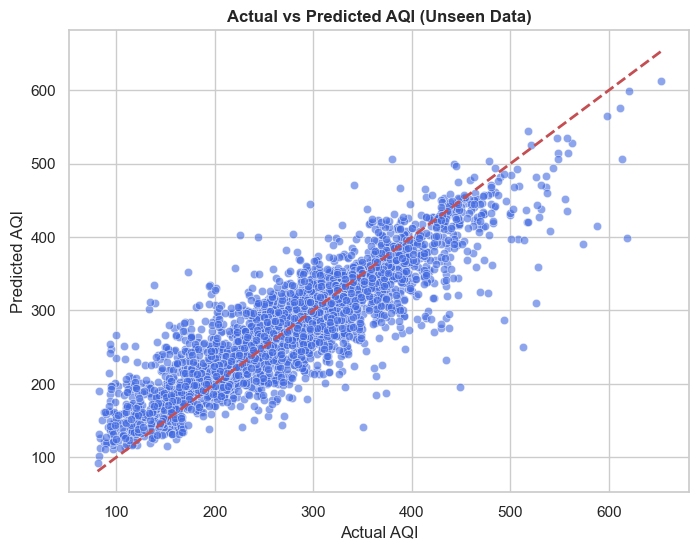

Generating SHAP Analysis (This may take a few seconds)...


In [ ]:
final_optimized_pipe = Pipeline([
    ('scaler', QuantileTransformer()), 
    ('reg', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=29,
        n_jobs=-1
    ))
])

X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])
final_optimized_pipe.fit(X_train_final, y_train_final)

print("untouched DATA Test\n")
y_test_pred = final_optimized_pipe.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_mae = mean_absolute_error(y_test, y_test_pred)
final_r2 = r2_score(y_test, y_test_pred)

print(f"FINAL UNSEEN RMSE: {final_rmse:.4f}")
print(f"FINAL UNSEEN MAE: {final_mae:.4f}")
print(f"FINAL UNSEEN R2: {final_r2:.4f}\n")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, color='royalblue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted AQI (Unseen Data)', fontweight='bold')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.show()


fitted_scaler = final_optimized_pipe.named_steps['scaler']
fitted_model = final_optimized_pipe.named_steps['reg']

X_test_scaled = fitted_scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance: How each pollutant drives the AQI", fontweight='bold')
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.show()